In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
data = pd.read_csv("synthetic_fibroids_data.csv")
data.head()

,Age,Race,BMI,Parity,Menarche_Age,Hypertension,PCOS,Vitamin_D_Deficient,Diet_Quality,Physical_Activity,Smoking,Family_History,Stress_Level,Has_Fibroids
0,43,Black,16.178451,0,14,1,0,0,1.575903,3.833420,0,0,5,1
1,29,Black,25.357003,2,12,0,1,1,2.364840,9.859261,1,0,7,0
2,22,Black,32.767817,1,15,0,0,0,3.658717,3.371890,0,1,7,1
3,35,Indian,24.406960,0,11,0,0,0,7.936650,5.721567,0,1,3,1
4,33,White,21.609689,2,12,0,0,0,7.379239,0.447680,0,0,9,1


In [8]:
# Basic info
print(data.info())
print("\nTarget distribution:")
print(data['Has_Fibroids'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2000 non-null   int64  
 1   Race                 2000 non-null   object 
 2   BMI                  2000 non-null   float64
 3   Parity               2000 non-null   int64  
 4   Menarche_Age         2000 non-null   int64  
 5   Hypertension         2000 non-null   int64  
 6   PCOS                 2000 non-null   int64  
 7   Vitamin_D_Deficient  2000 non-null   int64  
 8   Diet_Quality         2000 non-null   float64
 9   Physical_Activity    2000 non-null   float64
 10  Smoking              2000 non-null   int64  
 11  Family_History       2000 non-null   int64  
 12  Stress_Level         2000 non-null   int64  
 13  Has_Fibroids         2000 non-null   int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 218.9+ KB
None

Target distribution:
H

In [9]:
print("\nNumerical Features Summary:")
print(data.describe())


Numerical Features Summary:
               Age          BMI       Parity  Menarche_Age  Hypertension  \
count  2000.000000  2000.000000  2000.000000   2000.000000   2000.000000   
mean     32.282500    26.994846     1.453500     12.500500      0.207000   
std      10.255939     4.889028     1.149129      1.713029      0.405257   
min      15.000000    15.000000     0.000000     10.000000      0.000000   
25%      23.000000    23.702649     1.000000     11.000000      0.000000   
50%      32.000000    26.774474     1.000000     13.000000      0.000000   
75%      41.000000    30.311845     2.000000     14.000000      0.000000   
max      49.000000    40.844462     5.000000     15.000000      1.000000   

              PCOS  Vitamin_D_Deficient  Diet_Quality  Physical_Activity  \
count  2000.000000          2000.000000   2000.000000        2000.000000   
mean      0.094500             0.312000      5.089461           5.218240   
std       0.292596             0.463426      2.895091     

In [10]:
# Check for Missing values
print(data.isnull().sum())

Age                    0
Race                   0
BMI                    0
Parity                 0
Menarche_Age           0
Hypertension           0
PCOS                   0
Vitamin_D_Deficient    0
Diet_Quality           0
Physical_Activity      0
Smoking                0
Family_History         0
Stress_Level           0
Has_Fibroids           0
dtype: int64


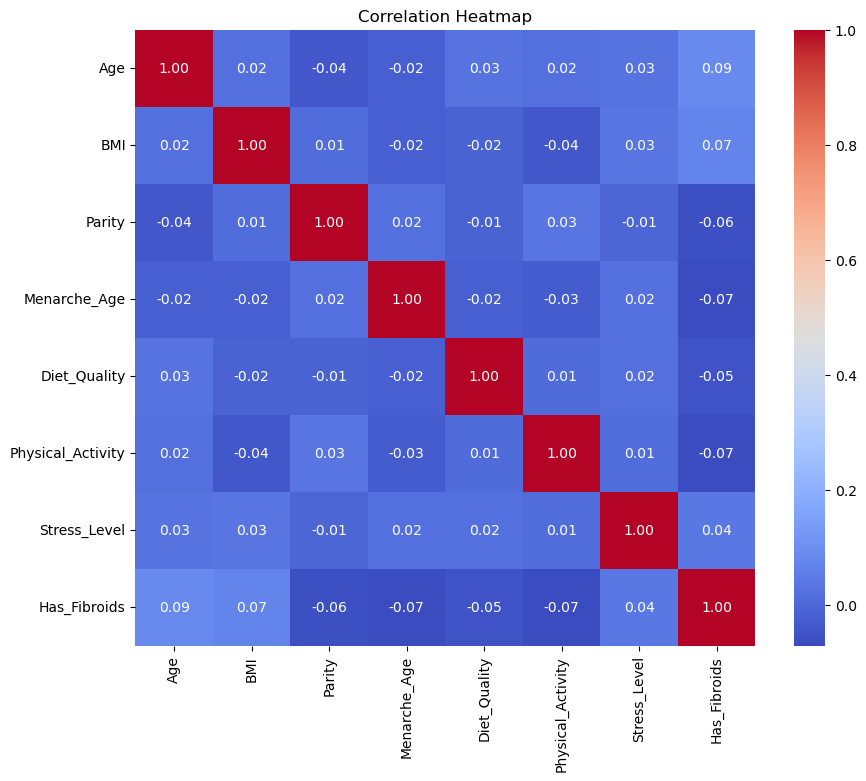

In [11]:
#Correlation heatmap(numericals only)
numerical_cols = ['Age', 'BMI', 'Parity', 'Menarche_Age', 'Diet_Quality', 'Physical_Activity', 'Stress_Level']
corr = data[numerical_cols + ['Has_Fibroids']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## What This Tells Us

The heatmap above shows pairwise correlations between all numeric features
in the dataset. The diagonal (all 1.00) simply represents each feature
correlated with itself.

All off-diagonal values fall between **-0.07 and +0.09**, indicating
virtually no linear relationship between any two features. This is
expected for a synthetic dataset and confirms that **multicollinearity
is not a concern** for this model — each feature contributes
independently to the prediction.

Notably, `Has_Fibroids` (the target variable) shows only weak
correlations with all predictors, with `Age` (0.09) and `BMI` (0.07)
being the strongest, albeit still negligible. This reflects the
complexity of fibroids as a condition — no single numeric factor
dominates in isolation.

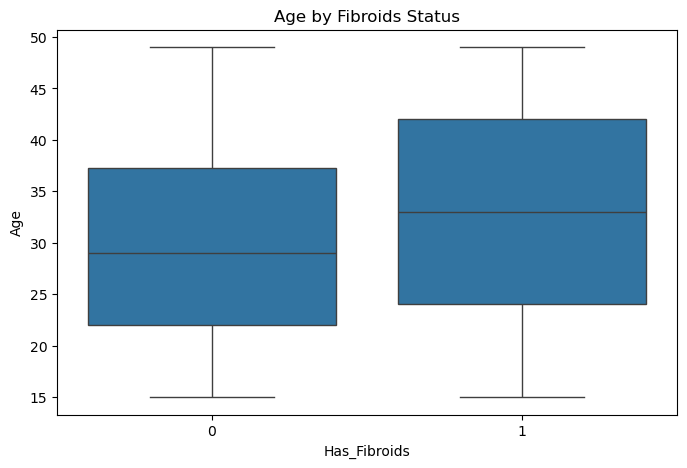

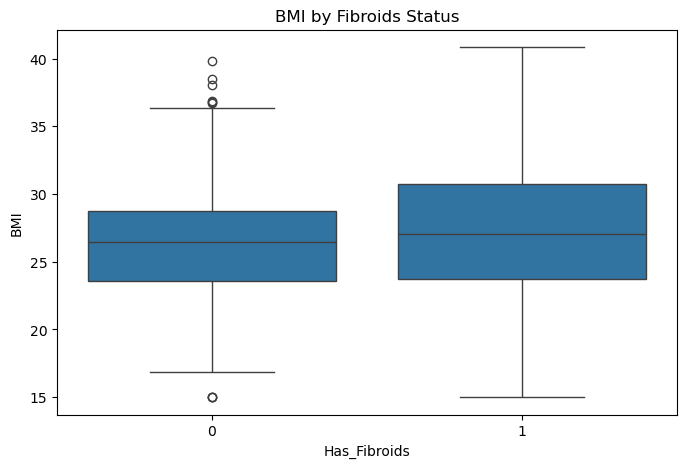

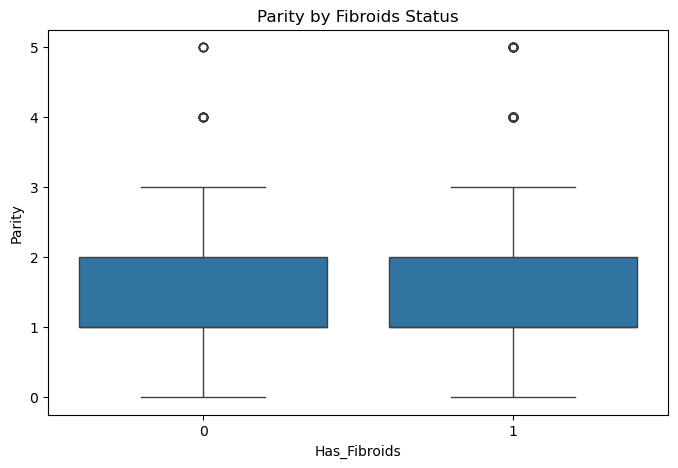

In [4]:
# Boxplots for key numerical features by target
for col in ['Age', 'BMI', 'Parity']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Has_Fibroids', y=col, data=data)
    plt.title(f'{col} by Fibroids Status')
    plt.show()

#### Age by Fibroids Status
Women without fibroids (0) tend to be younger, with a median around 32 and an IQR roughly spanning 25–37. Women with fibroids (1) skew older, with a median closer to 35 and a wider spread of 30–42. This aligns with established epidemiology — fibroid prevalence rises significantly with age, particularly after 35.

#### BMI by Fibroids Status
Both groups share a similar median BMI (around 27), but women with fibroids show a slightly higher median and wider upper range, suggesting a modest association between higher BMI and fibroid presence. A few low-BMI outliers appear in the non-fibroid group. This is consistent with literature linking adiposity to elevated estrogen levels, which may promote fibroid growth.

#### Parity by Fibroids Status
The parity distributions are nearly identical across both groups — median of ~1–2 pregnancies, IQR of 1–2, and outliers at 4–5 for both. This suggests parity alone may not be a strong differentiator in this synthetic dataset, though clinically, nulliparity (0 pregnancies) is a known risk factor. The lack of separation here may reflect the relatively modest probability bump assigned to Parity == 0 in the data generation logic.

#### KEY TAKEAWAYS
Age is the clearest factor separating women with and without fibroids. BMI shows a small difference, and number of pregnancies shows almost none.

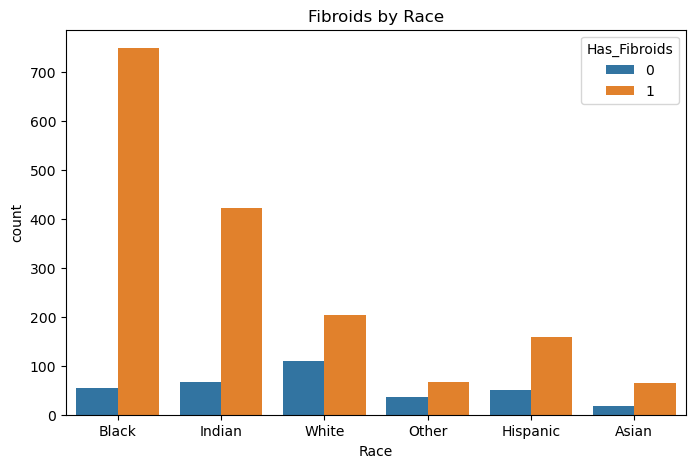

In [15]:
# Countplot for categorical (e.g., Race)
plt.figure(figsize=(8, 5))
sns.countplot(x='Race', hue='Has_Fibroids', data=data)
plt.title('Fibroids by Race')
plt.show()

#### Racial Disparity
Black women show the most dramatic disparity — the fibroid-positive count (~750) is roughly 13x higher than the fibroid-negative count (~55), indicating an extremely high prevalence rate within this group.
Indian women follow a similar pattern, with fibroid-positive cases (~425) far exceeding negatives (~70), reflecting the elevated risk weight assigned during data generation.

### MODEL CREATION & BASELINE TRAINING

In [16]:
# Import model creation libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                             recall_score, classification_report)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

In [18]:
# Features and targets
X = data.drop('Has_Fibroids', axis=1)
y = data['Has_Fibroids']

In [22]:
# Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.20,
    random_state = 42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples : {X_test.shape[0]:,}")
print(f"Positive class in train: {y_train.mean():.1%}")

Training samples: 1,600
Testing samples : 400
Positive class in train: 83.2%


In [23]:
# Preprocessing Pipeline
cat_cols = ['Race']
num_cols = ['Age', 'BMI', 'Parity', 'Menarche_Age', 'Hypertension', 'PCOS',
            'Vitamin_D_Deficient', 'Diet_Quality', 'Physical_Activity',
            'Smoking', 'Family_History', 'Stress_Level']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

### Model 1: Logistic Regression (Baseline)

In [25]:
print("Training Logistic Regression (Baseline)")

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_lr):.4f}")

Training Logistic Regression (Baseline)

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.35      0.66      0.46        67
           1       0.92      0.76      0.83       333

    accuracy                           0.74       400
   macro avg       0.63      0.71      0.64       400
weighted avg       0.82      0.74      0.77       400

AUC-ROC : 0.8238


### Model 2: XGBoost (Main Model)

In [ ]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, roc_auc_score

print("Training XGBoost Model with SMOTE")

xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        random_state=42,
        use_label_encoder=False
    ))
])

# Train the model
xgb_pipeline.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Results
print("\nXGBoost + SMOTE Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_xgb):.4f}")

Training XGBoost Model with SMOTE


  File "c:\Users\wisdo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\wisdo\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\wisdo\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\wisdo\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



XGBoost + SMOTE Results:
              precision    recall  f1-score   support

           0       0.43      0.28      0.34        67
           1       0.87      0.92      0.89       333

    accuracy                           0.82       400
   macro avg       0.65      0.60      0.62       400
weighted avg       0.79      0.82      0.80       400

AUC-ROC : 0.7815


In [30]:
#Random Forest v2
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=6,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_rf):.4f}")


Random Forest Results:
              precision    recall  f1-score   support

           0       0.38      0.60      0.47        67
           1       0.91      0.80      0.85       333

    accuracy                           0.77       400
   macro avg       0.64      0.70      0.66       400
weighted avg       0.82      0.77      0.79       400

AUC-ROC : 0.8146


In [33]:
# Model Comparison
print("MODEL COMPARISON SUMMARY")

models = {
    'Logistic Regression': (y_pred_lr,        y_prob_lr),
    'XGBoost + SMOTE':     (y_pred_xgb, y_prob_xgb),
    'Random Forest':       (y_pred_rf,        y_prob_rf)
}

results = []
for model_name, (y_pred, y_prob) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model':          model_name,
        'Accuracy':       round(report['accuracy'], 4),
        'Class 0 Recall': round(report['0']['recall'], 4),
        'Class 0 F1':     round(report['0']['f1-score'], 4),
        'Class 1 Recall': round(report['1']['recall'], 4),
        'Class 1 F1':     round(report['1']['f1-score'], 4),
        'AUC-ROC':        round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

MODEL COMPARISON SUMMARY
                     Accuracy  Class 0 Recall  Class 0 F1  Class 1 Recall  Class 1 F1  AUC-ROC
Model                                                                                         
Logistic Regression    0.7400          0.6567      0.4583          0.7568      0.8289   0.8238
XGBoost + SMOTE        0.8175          0.2836      0.3423          0.9249      0.8940   0.7815
Random Forest          0.7700          0.5970      0.4651          0.8048      0.8535   0.8146


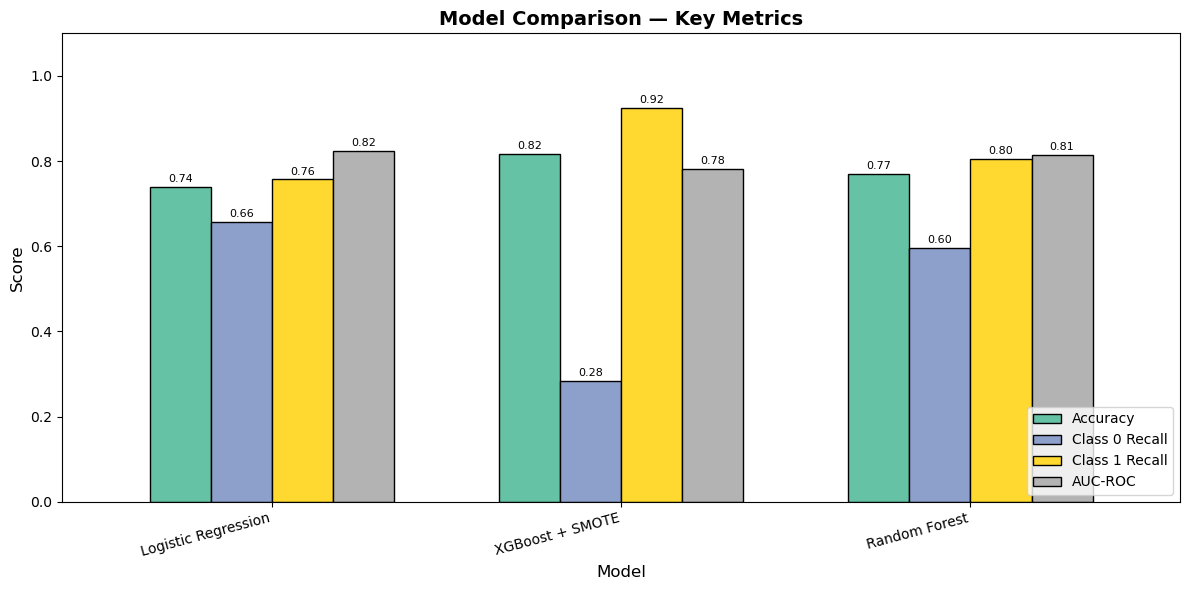

In [37]:
# Accuracy Visualized
metrics_to_plot = ['Accuracy', 'Class 0 Recall', 'Class 1 Recall', 'AUC-ROC']
plot_df = results_df[metrics_to_plot]

ax = plot_df.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='Set2',
    edgecolor='black',
    width=0.7
)

plt.title('Model Comparison — Key Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.show()


In [35]:
# Best model to use
best_model = results_df['AUC-ROC'].idxmax()
best_auc   = results_df['AUC-ROC'].max()
print(f"\n Best Model by AUC-ROC: {best_model} ({best_auc:.4f})")


 Best Model by AUC-ROC: Logistic Regression (0.8238)


In [38]:
# Retrain final clean pipeline using Logistic Regression
final_lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        solver='liblinear'
    ))
])

final_lr_pipeline.fit(X_train, y_train)

# Final predictions on test set
y_pred_final = final_lr_pipeline.predict(X_test)
y_prob_final = final_lr_pipeline.predict_proba(X_test)[:, 1]

print("\nFinal Logistic Regression Performance on Test Set:")
print(classification_report(y_test, y_pred_final))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")


Final Logistic Regression Performance on Test Set:
              precision    recall  f1-score   support

           0       0.35      0.66      0.46        67
           1       0.92      0.76      0.83       333

    accuracy                           0.74       400
   macro avg       0.63      0.71      0.64       400
weighted avg       0.82      0.74      0.77       400

AUC-ROC : 0.8238
F1-Score: 0.8289


In [40]:
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import joblib

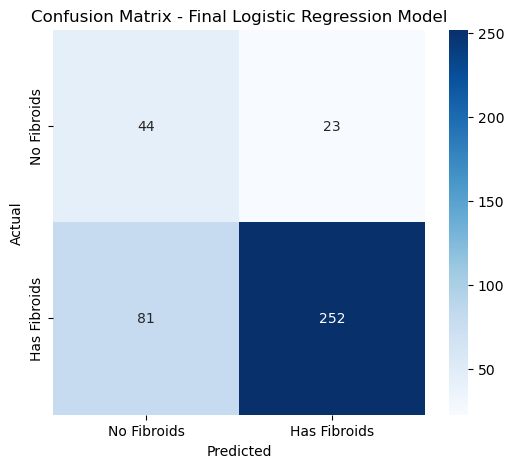

In [41]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fibroids', 'Has Fibroids'],
            yticklabels=['No Fibroids', 'Has Fibroids'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Logistic Regression Model')
plt.show()

In [42]:
# Save final model
joblib.dump(final_lr_pipeline, 'uf_fibroids_final_model.pkl')
joblib.dump(preprocessor, 'uf_preprocessor.pkl')

print("\n Final model saved successfully!")
print("   • uf_fibroids_final_model.pkl     ← Main production model (Logistic Regression)")
print("   • uf_preprocessor.pkl             ← Preprocessing pipeline")


 Final model saved successfully!
   • uf_fibroids_final_model.pkl     ← Main production model (Logistic Regression)
   • uf_preprocessor.pkl             ← Preprocessing pipeline


In [45]:
# Feature Importance

# Get feature names after one-hot encoding
cat_feature_names = final_lr_pipeline.named_steps['preprocessor']\
                    .named_transformers_['cat'].get_feature_names_out(cat_cols)

feature_names = num_cols + list(cat_feature_names)

coefficients = final_lr_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.round(4).head(12))   # Show top 12 features

# Save for your report
coef_df.to_csv('logistic_regression_coefficients.csv', index=False)

                Feature  Coefficient  Odds Ratio
12           Race_Black       1.5829      4.8689
14          Race_Indian       0.9399      2.5597
10       Family_History       0.9242      2.5197
6   Vitamin_D_Deficient       0.4397      1.5522
1                   BMI       0.2631      1.3009
4          Hypertension       0.2451      1.2777
5                  PCOS       0.2304      1.2591
0                   Age       0.2254      1.2529
11         Stress_Level       0.1429      1.1536
9               Smoking      -0.1192      0.8876
13        Race_Hispanic      -0.1276      0.8802
7          Diet_Quality      -0.1741      0.8402
